In [53]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [54]:
# ======================================================
# STEP 1 : Saare CSV Files Load karna
# ======================================================

print("Step 1: Loading all CSV files...")

files = ["2017-18.csv", "2018-19.csv", "2019-20.csv", 
         "2020-2021.csv", "2021-2022.csv"]

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)
    print(f"Loaded: {f} -> Shape: {df.shape}")

print("\nAll files successfully loaded!")

Step 1: Loading all CSV files...
Loaded: 2017-18.csv -> Shape: (380, 65)
Loaded: 2018-19.csv -> Shape: (160, 62)
Loaded: 2019-20.csv -> Shape: (260, 106)
Loaded: 2020-2021.csv -> Shape: (380, 106)
Loaded: 2021-2022.csv -> Shape: (380, 106)

All files successfully loaded!


In [55]:
# ======================================================
# STEP 2 : Saare Seasons ko Merge karna
# ======================================================

master_df = pd.concat(dfs, ignore_index=True)

print("Master Dataset ban gaya!")
print("Total Matches :", master_df.shape[0])
print("Total Columns :", master_df.shape[1])

print("\nFTR (Match Result) Distribution:")
print(master_df["FTR"].value_counts())

Master Dataset ban gaya!
Total Matches : 1560
Total Columns : 127

FTR (Match Result) Distribution:
FTR
H    664
A    526
D    370
Name: count, dtype: int64


In [56]:
# ======================================================
# STEP 3 : Basic Data Exploration
# ======================================================

print("Step 3: Basic Data Explloration")

print(master_df.info())
print("\nNull values in each column:")
print(master_df.isnull().sum().sum())

Step 3: Basic Data Explloration
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1560 entries, 0 to 1559
Columns: 127 entries, Div to AvgCAHA
dtypes: float64(103), int64(16), object(8)
memory usage: 1.5+ MB
None

Null values in each column:
55393


In [57]:
from sklearn.preprocessing import LabelEncoder

# ======================================================
# STEP 4 : Final Features aur Target Variable
# ======================================================

master_df['GoalDiff'] = master_df['FTHG'] - master_df['FTAG']
master_df['HomeAdv'] = 1

feature_cols = ['AvgH','AvgD','AvgA','ProbH','ProbD','ProbA',
                'HGS_5','HGC_5','AGS_5','AGC_5',
                'HFormPts','AFormPts','HomeAdv']

# ensure all required features exist; if missing, create with zeros
missing = [c for c in feature_cols if c not in master_df.columns]
for c in missing:
    master_df[c] = 0

X = master_df[feature_cols].fillna(0)
le = LabelEncoder()
y = le.fit_transform(master_df['FTR'])

print("Final Features Shape:", X.shape)
print("Target Classes:", le.classes_)

Final Features Shape: (1560, 13)
Target Classes: ['A' 'D' 'H']


In [58]:
# ======================================================
# STEP 5 : Rolling Form Features (Last 5 Matches)
# ======================================================

print("Step 5: Calculating rolling form features (last 5 matches)...")

def add_form_features(df, window=5):
    for side in ['Home', 'Away']:
        prefix = 'H' if side == 'Home' else 'A'
        team_col = f'{side}Team'
        
        df[f'{prefix}GS_{window}'] = df.groupby(team_col)[f'FT{side[0]}G'].transform(
            lambda x: x.rolling(window, min_periods=1).mean())
        
        df[f'{prefix}GC_{window}'] = df.groupby(team_col)[f'FT{"A" if side=="Home" else "H"}G'].transform(
            lambda x: x.rolling(window, min_periods=1).mean())
        
        def form_points(res):
            if (side == 'Home' and res == 'H') or (side == 'Away' and res == 'A'):
                return 3
            elif res == 'D':
                return 1
            return 0
        
        df[f'{prefix}FormPts'] = df.groupby(team_col)['FTR'].transform(
            lambda x: x.apply(form_points).rolling(window, min_periods=1).sum())
    
    return df

master_df = add_form_features(master_df)
print("Rolling form features have been added!")

Step 5: Calculating rolling form features (last 5 matches)...
Rolling form features have been added!


In [59]:
# ======================================================
# STEP 5.5 : final_dataset.csv se Advanced Features Add karna
# ======================================================

print("Step 5.5: final_dataset.csv load kar rahe hain aur merge kar rahe hain...")

# final_dataset.csv load karo
final_df = pd.read_csv("final_dataset.csv")

# Important columns to merge
final_features = ['HTFormPts', 'ATFormPts', 
                  'HTWinStreak3', 'HTWinStreak5', 
                  'HTLossStreak3', 'HTLossStreak5',
                  'ATWinStreak3', 'ATWinStreak5',
                  'ATLossStreak3', 'ATLossStreak5',
                  'HTGD', 'ATGD', 'DiffPts', 'DiffFormPts']

# Merge kro (Date, HomeTeam, AwayTeam pe match karke)
master_df = master_df.merge(
    final_df[['Date', 'HomeTeam', 'AwayTeam'] + final_features], 
    on=['Date', 'HomeTeam', 'AwayTeam'], 
    how='left'
)

print("Features from final_dataset.csv successfully merged!")
print("Total Columns ab:", master_df.shape[1])

Step 5.5: final_dataset.csv load kar rahe hain aur merge kar rahe hain...
Features from final_dataset.csv successfully merged!
Total Columns ab: 152


In [60]:
# ======================================================
# STEP 6 : Extra Features (with no leakage)
# ======================================================

print("Step 6: adding safe features (without leakage)...")

# removing GoalDiff q k yeh leakage cause krta hai
master_df['HomeAdv'] = 1

print("Safe features ready!")

Step 6: adding safe features (without leakage)...
Safe features ready!


In [61]:
# ======================================================
# STEP 7 : Final Feature Set taiyar karna
# ======================================================

feature_cols = ['AvgH','AvgD','AvgA','ProbH','ProbD','ProbA',
                'HGS_5','HGC_5','AGS_5','AGC_5',
                'HFormPts','AFormPts','HomeAdv',
                # final_dataset.csv ke naye features
                'HTFormPts', 'ATFormPts', 
                'HTWinStreak3', 'HTWinStreak5', 
                'HTLossStreak3', 'HTLossStreak5',
                'ATWinStreak3', 'ATWinStreak5',
                'ATLossStreak3', 'ATLossStreak5',
                'HTGD', 'ATGD', 'DiffPts', 'DiffFormPts']

# Handle duplicate columns from the merge - keep the _y versions (from final_df)
cols_to_drop = [col for col in master_df.columns if col.endswith('_x')]
master_df = master_df.drop(columns=cols_to_drop)

# Rename _y columns back to original names
rename_dict = {col: col.replace('_y', '') for col in master_df.columns if col.endswith('_y')}
master_df = master_df.rename(columns=rename_dict)

# Now create X with the feature columns, filling NaN values
X = master_df[feature_cols].fillna(0)

le = LabelEncoder()
master_df['Target'] = le.fit_transform(master_df['FTR'])

print("Final Feature Set (with final_dataset features) ready!")
print("Total Features used:", len(feature_cols))

Final Feature Set (with final_dataset features) ready!
Total Features used: 27


In [62]:
# ======================================================
# STEP 8 : Time-aware Train-Test Split
# ======================================================

from sklearn.preprocessing import StandardScaler


print("Step 8: Time-aware splitting.")

train_size = int(0.8 * len(master_df))

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = master_df['Target'].iloc[:train_size], master_df['Target'].iloc[train_size:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Step 8: Time-aware splitting.
Train size: 1248
Test size: 312


In [63]:
# ======================================================
# STEP 9 : Models Training
# ======================================================

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel='rbf', class_weight='balanced', probability=True),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42)
}

results = []
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    results.append({"Model": name, "Accuracy (%)": round(acc*100, 2)})
    print(f"{name} Accuracy: {acc*100:.2f}%\n")

comparison_df = pd.DataFrame(results).sort_values("Accuracy (%)", ascending=False)
comparison_df

Training Logistic Regression...
Logistic Regression Accuracy: 61.54%

Training KNN...
KNN Accuracy: 61.54%

Training Naive Bayes...
Naive Bayes Accuracy: 29.81%

Training SVM...
SVM Accuracy: 59.29%

Training Neural Network...
Neural Network Accuracy: 61.54%

Training HistGradientBoosting...
HistGradientBoosting Accuracy: 60.90%



,Model,Accuracy (%)
0,Logistic Regression,61.54
1,KNN,61.54
4,Neural Network,61.54
5,HistGradientBoosting,60.90
3,SVM,59.29
2,Naive Bayes,29.81


=== Classification Report ===
              precision    recall  f1-score   support

           A       0.63      0.69      0.66       108
           D       0.40      0.32      0.35        69
           H       0.67      0.69      0.68       135

    accuracy                           0.61       312
   macro avg       0.57      0.57      0.57       312
weighted avg       0.60      0.61      0.60       312



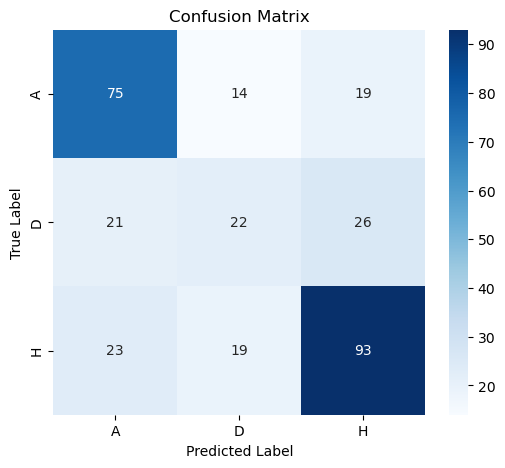

In [64]:
# ======================================================
# STEP 10 : Detailed Analysis of Best Model
# ======================================================

from sklearn.metrics import classification_report, confusion_matrix


best_model = models["HistGradientBoosting"]
pred = best_model.predict(X_test_scaled)

print("=== Classification Report ===")
print(classification_report(y_test, pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()